# Chapter 3 Excercises. ISLP

In [2]:
# Libraries
import numpy as np
from matplotlib.pyplot import subplots
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [3]:
# Functions from ISLP Package
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

## Excercise 8:

In [ ]:
# Loading the data set for the excercise
Auto = load_data('Auto')
Auto

In [4]:
# Function that adds a line to an existing plot
def abline(ax, b, m, *args, **kwargs):
    # *args = any number of non-named arguments
    # **kwargs = any number of named arguments
    # Add a line with slope m and intercept b to ax
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

In [ ]:
# Model matrix
X = MS(['horsepower']).fit_transform(Auto)
# Response matrix
y = Auto['mpg']

In [ ]:
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

The effectively p-value of zero for the slope indicates that there´s a clear relation between mpg and horsepower. This relation is negative, but the small value indicates that it might not be of much value, or that the true relation might vary from a linear form. 

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(Auto['horsepower'], Auto['mpg'])
ax.set_title("Horsepower vs MPG")
ax.set_xlabel("Horsepower")
ax.set_ylabel("Miles per Gallon")
abline(ax, 
       results.params[0],                       # Intercept
       results.params[1],                       # Slope
       'r--',                                   # Red dashed line
       linewidth=3                              # Increased linewidth
       )

We also predict the value for mpg associated with a horsepower of 98:

In [ ]:
design = MS(['horsepower'])
new_df = pd.DataFrame({'horsepower':[98]})
new_df

In [ ]:
# Manually creating the matrix to perform predictions
newX = pd.DataFrame({'intercept':np.ones(new_df.shape[0]),
                     'horsepower':new_df['horsepower']}
                     )
newX

In [ ]:
# Generates the prediction for horsepower=98
predictions = results.get_prediction(newX)
predictions.predicted_mean

In [ ]:
# 95% Confidence interval for the prediction
predictions.conf_int(alpha=0.5)

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_title('Residuals plot')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')           # Adds a horizontal line at 0

The residuals plot shows a clear U-shape pattern, which indicates that, most likely, the relation between horsepower and mpg is not linear.

## Excercise 9:

In [ ]:
# Scatterplot matrix that includes all the variables in the data set Auto
pd.plotting.scatter_matrix(Auto)

In [ ]:
Auto.columns

In [ ]:
CorrMatrix = Auto.corr()
CorrMatrix

In [ ]:
# Creates a list of all variables except mpg
predictors = list(Auto.columns.drop('mpg'))


In [ ]:
# Model Matrix
X = MS(predictors).fit_transform(Auto)
# Response matrix
Y = Auto['mpg']

In [ ]:
# Model
model2 = sm.OLS(Y, X)
results2 = model2.fit()
summarize(results2)

Both Horsepower and Acceleration show high p-values. In the scatter plot above, there seems to be a linear relationship between this two variables, which might explain the high p-values, as can be seen in the next plot:

In [ ]:
Auto.plot.scatter('horsepower', 'acceleration')

On the other hand, most of the other variables, except for cylinders, appear to have a statistically significant relationship with mpg. 

In [ ]:
anova_lm(results, results2)

Let's include an interaction term between horsepower and acceleration and see how it changes the model:

In [ ]:
predictors.append(('horsepower', 'acceleration'))

In [ ]:
# New model matrix
X = MS(predictors).fit_transform(Auto)
# Response matrix
Y = Auto['mpg']

In [ ]:
model3 = sm.OLS(Y, X)
results3 = model3.fit()
summarize(results3)

The p-value of both horsepower and acceleration became practically zero, but it increased for cylinders and displacement. Let's see if the model improved:

In [ ]:
anova_lm(results2, results3)

The new model shows an apparen improvement over the previous one.

In [ ]:
# We produce a Residuals plot for the original multiple regression model
ax = subplots(figsize=(8,8))[1]
ax.scatter(results2.fittedvalues, results2.resid)
ax.set_title('Residuals plot (first model)')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

In [ ]:
# We produce a Residuals plot for the original multiple regression model
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_title('Residuals plot (second model)')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

Both residuals plots indicate that the best model to predict mpg might not be linear. Let's try now with a cuadratic regression on the horsepower variable.

In [ ]:
X = MS([poly('horsepower', degree=2)]).fit_transform(Auto)
model4 = sm.OLS(y, X)
results4 = model4.fit()
summarize(results4)

In [ ]:
anova_lm(results, results4)

The cuadratic model shows improvement over the original linear model for the prediction.

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results4.fittedvalues, results4.resid)
ax.set_title('Residuals plot (quadratic model)')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

There's no discernible pattern, wich might indicate that the quadratic model is a good fit for predicting mpg on the basis of horsepower.

## Excercise 10:
This excercise uses the "Carseats" data set. We'll fit a multiple regressionn model to predict **Sales** using the variables **Price**, **Urban**, and **US**.

In [ ]:
Carseats = load_data('Carseats')
Carseats

In [ ]:
# Model Matrix
X = MS(['Price', 'Urban', 'US']).fit_transform(Carseats)
X[:4]

In [ ]:
# Response Matrix
Y = Carseats['Sales']
Y

In [ ]:
# We create the model and summarize the results
model = sm.OLS(Y, X)
results = model.fit()
summarize(results)

The intercep, Price and US[yes] coefficiens show p-values of effectively zero, and thus they are statistically signifficant. On the other hand the coefficient for Urban[yes] shows a p-value of almost one, which indicates that we can´t reject the null hypothesis of its coefficient being zero.
We can see the model as follows:
$$ 
\text{Sales} = \begin{cases} 
                    \beta_{0} + \beta_{1}\times \text{Price} + \beta_{2} + \beta_{3}, & \text{if both Urban and US}\\
                    \beta_{0} + \beta_{1}\times \text{Price} + \beta_{2}, & \text{if only Urban}\\
                    \beta_{0} + \beta_{1}\times \text{Price} + \beta_{3}, & \text{if only US}\\
                    \beta_{0} + \beta_{1}\times \text{Price}, & \text{if neither}
               \end{cases}
$$
Where we have that $\beta_{0}=13.0435$, $\beta_{1}=-0.0545$, $\beta_{2}=-0.0219$, and $\beta_{3}=1.2006$.
The only predictor for which we can't reject the null hypothesis is for $\beta_{2}$, that is, we can't reject that
$$H_{0}:\beta_{2}=0.$$
This evidence suggest that it might be better to fit a smaller model removing the **Urban** variable.

In [ ]:
# New model matrix
newX = MS(['Price', 'US']).fit_transform(Carseats)
newX[:4]

In [ ]:
# New model and results after removing Urban
model2 = sm.OLS(Y, newX)
results2 = model2.fit()
summarize(results2)

In [ ]:
anova_lm(results, results2)

This F-statistic suggests that removing the Urban variable didn't really alter the model.

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results2.fittedvalues, results2.resid)
ax.set_title('Residuals plot')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

As we see there's no pattern in the residuals, wich indicates that the linear model might be a good fit for the data. Also, as the residuals are very spread, there's no indication of any outlier.

In [ ]:
# Confidence interval for the predictors
results2.conf_int(alpha=0.5)

We'll now search for high leverage observations in the second model

In [ ]:
# Leverage Plot
infl = results2.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(newX.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)             # Identifies the index of the largest element of an array

We can clearly see that the observation with index 42 is a clear high leverage point.

## Excercise 11
This problem focuses on the t-statistic for the null hypothesis $H_{0}:\beta=0$ for a model without an intercept.

In [ ]:
# We generate a predictor x and a response y
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

In [ ]:
# Model Matrix
X = pd.DataFrame({'x':x})
# Response Matrix
Y = pd.DataFrame({'y':y})

First we'll make a linear regression of y onto x, without an intercept, and then we'll do the same but this time with a model of x onto y.

In [ ]:
# Model of y onto x
model1 = sm.OLS(Y, X)
results1 = model1.fit()
summarize(results1)

In [ ]:
# Model of x onto y
model2 = sm.OLS(X, Y)
results2 = model2.fit()
summarize(results2)

The t-statistic for the regression of y onto x is the same as the t-statistic for the regression of x onto y. It can be shown that when regression is performed *with* an intercept, the t-statistic for $H_{0}:\beta_{1}=0$ is the same for the regression of y onto x as it is for the regression of x onto y.

## Excercise 13
In this problem, we'll create simulated data and will fit simple linear regression models to it.

In [ ]:
# We create a random number generator (rng) and use it to create a vector x with 100 observations
rng = np.random.default_rng(1)
x = rng.normal(size = 100)                      # We generate the numbers from a N(0,1) distribution

In [ ]:
# Vector of 100 random numbers generated from a N(0,0.25) distribution. eps is short for epsilon
eps = rng.normal(scale = 0.25, size = 100)

We now generate a vector *y* following the model
$$Y = -1 + 0.5X +\epsilon.$$
The coefficients for this linear model are $\beta_{0}=-1$ and $\beta_{1}=0.5$.

In [5]:
y = -1 + 0.5*x + eps

Text(0, 0.5, 'y')

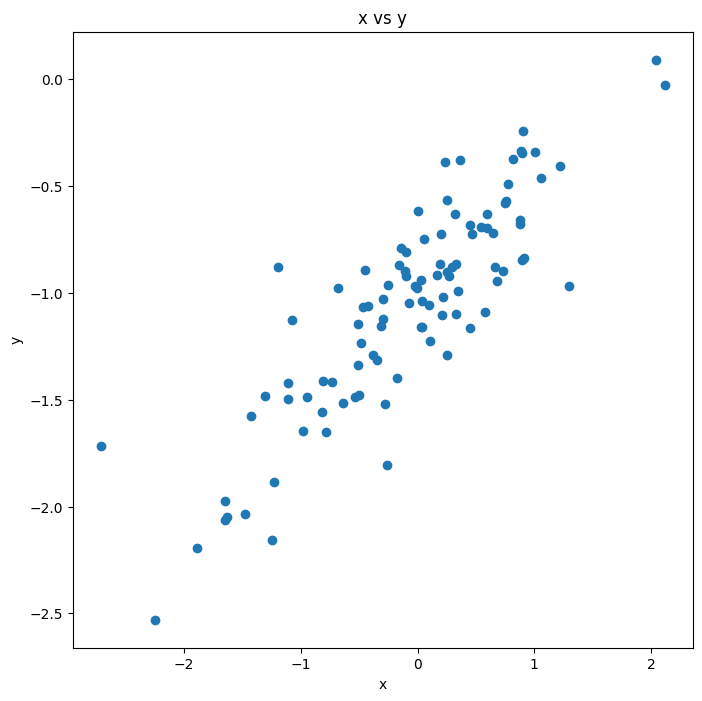

In [8]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y)
ax.set_title('x vs y')
ax.set_xlabel('x')
ax.set_ylabel('y')

As expected, the relationship between x and y is very clearly a linear relationship (because we built it that way). We'll now procede to fit a model to this data and see how it behaves.

In [ ]:
# We create a model matrix (basically by adding constat row for the intercept)
X = pd.DataFrame({'intercept':np.ones(100),
                  'x':x})

In [13]:
# We generate a model and summarize the results
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-1.0190,0.025,-40.537,0.0
x,0.4921,0.029,16.734,0.0


We can see that the estimated coefficients $\hat{\beta_{0}}$ and $\hat{\beta_{1}}$ are actually really close to the true value of $\beta_{0}$ and $\beta_{1}$.

C:\Users\vavic\AppData\Local\Temp\ipykernel_11168\1247521512.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3, label='Simple regression model')


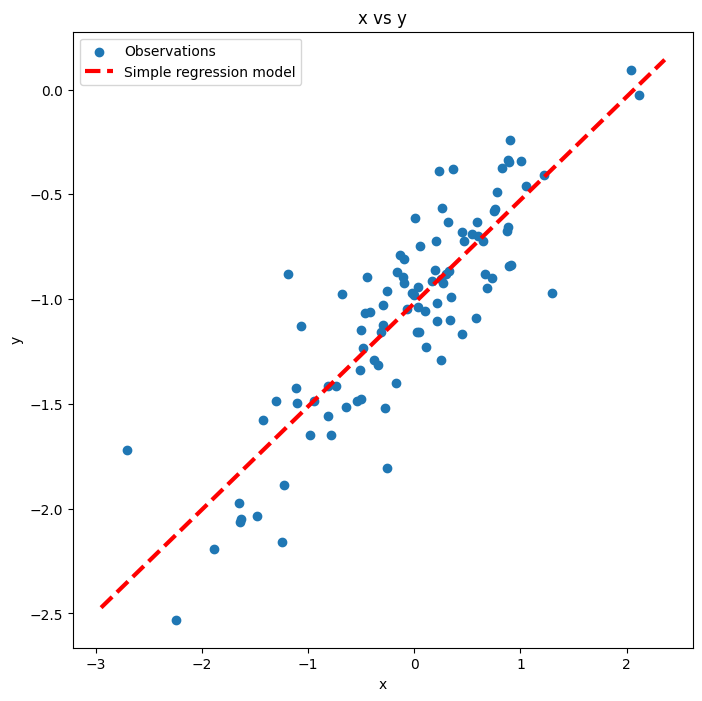

In [18]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y, label='Observations')
abline(ax, results.params[0], results.params[1], 'r--', linewidth=3, label='Simple regression model')
ax.set_title('x vs y')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()

What happens if we fit a quadratic model?

In [24]:
X2 = MS([poly('x', degree=2)]).fit_transform(X)
X2[:4]


,intercept,"poly(x, degree=2)[0]","poly(x, degree=2)[1]"
0,1.0,0.049227,-0.036584
1,1.0,0.105129,0.034593
2,1.0,0.047448,-0.038177
3,1.0,-0.144388,0.032896


In [25]:
model2 = sm.OLS(y, X2)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,-1.0552,0.025,-41.920,0.000
"poly(x, degree=2)[0]",4.1909,0.252,16.649,0.000
"poly(x, degree=2)[1]",-0.0131,0.252,-0.052,0.959


As we can see, the p-value for $\hat{\beta_{2}}$ the coefficient of the quadratic term is almost one, and thus we can´t reject the null hypothesis $H_{0}:\beta_{2}=0$.
Now let's see what happens if we decrease the noise (less error), and then what happens if we increase the noise (more error). For this we'll create two new error terms $\epsilon_{2}$ and $\epsilon_{3}$, and use them to create two new groups of observations $y_{2}$ and $y_{3}$.

In [26]:
eps2 = rng.normal(scale=0.1, size=100)              # epsilon from a N(0,0.1) distribution
eps3 = rng.normal(size=100)                         # epsilon from a N(0,1) distribution

In [27]:
y2 = -1 + 0.5*x + eps2
y3 = -1 + 0.5*x + eps3

First we'll look into the less noise one, y2.

In [28]:
model2 = sm.OLS(y2, X)
results2 = model2.fit()
summarize(results2) 

,coef,std err,t,P>|t|
intercept,-1.0162,0.009,-109.770,0.0
x,0.4987,0.011,46.046,0.0


The coefficient estimates are still really close to the actual values, and even closer.

C:\Users\vavic\AppData\Local\Temp\ipykernel_11168\732208357.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results2.params[0], results2.params[1], 'g--', linewidth=3, label='Simple regression model')


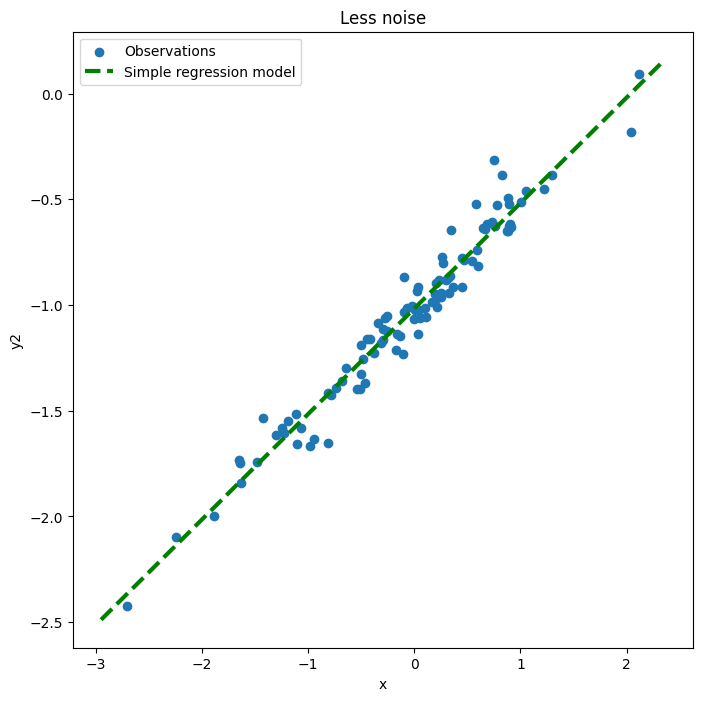

In [29]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y2, label='Observations')
abline(ax, results2.params[0], results2.params[1], 'g--', linewidth=3, label='Simple regression model')
ax.set_title('Less noise')
ax.set_xlabel('x')
ax.set_ylabel('y2')
ax.legend()

Now for the simulation with more noise.

In [30]:
model3 = sm.OLS(y3, X)
results3 = model3.fit()
summarize(results3) 

,coef,std err,t,P>|t|
intercept,-1.0092,0.087,-11.539,0.0
x,0.6470,0.102,6.323,0.0


The estimates became larger, and they are further away from the real predictions than the previous two.

C:\Users\vavic\AppData\Local\Temp\ipykernel_11168\3551896814.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results3.params[0], results3.params[1], 'y--', linewidth=3, label='Simple regression model')


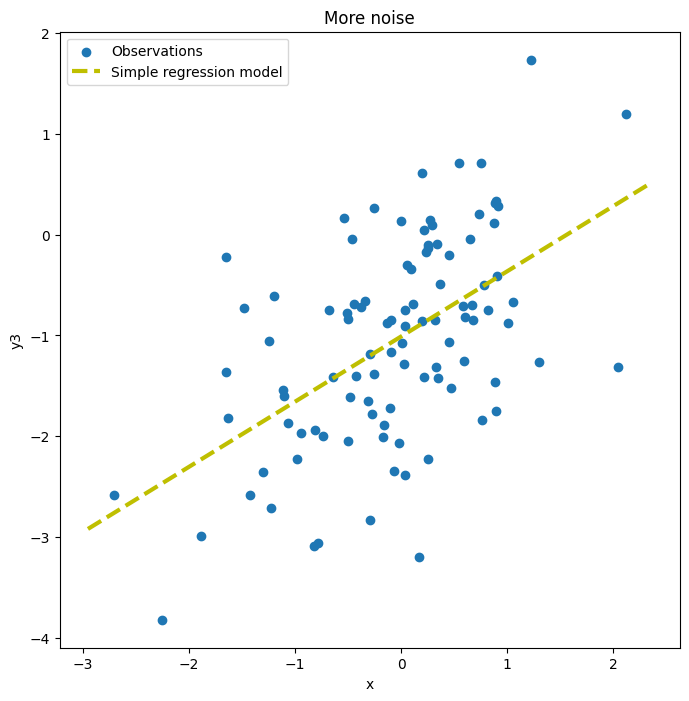

In [32]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y3, label='Observations')
abline(ax, results3.params[0], results3.params[1], 'y--', linewidth=3, label='Simple regression model')
ax.set_title('More noise')
ax.set_xlabel('x')
ax.set_ylabel('y3')
ax.legend()

This new plot shows clearly that, as noise increases, it becomes harder to predict the true coefficients for the real relation between the response Y and the predictor X.
Lastly, we show the confidence intervals for each of the coefficients. 

In [37]:
all_results = [results, results2, results3]
for result in all_results:
    print(result.conf_int(alpha=0.5))

                  0         1
intercept -1.036025 -1.001988
x          0.472235  0.512056
                  0         1
intercept -1.022460 -1.009925
x          0.491389  0.506054
                  0         1
intercept -1.068366 -0.949952
x          0.577724  0.716264


We see that the confidence interval is wider for the model with more noise, and thiner when the noise is reduced, while the original model lies somewhere around the middle.

## Excercise 14
In this problem we'll focus on the *collinearity* problem.

In [5]:
# Random number generator with predetermined seed
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)                    # Vector with 100 samples from a uniform distribution
x2 = 0.5 * x1 + rng.normal(size=100) / 10           # Vector with 100 samples as a function of x1
y = 2 + 2*x1 + 0.3*x2 + rng.normal(size=100)        # Linear response were y is a function of x1 and x2

Here we have the **true** function (and coefficients) for our response Y, given by
$$Y = 2 + 2X_{1} + 0.3X_{2} + \epsilon.$$

Text(0, 0.5, 'X2')

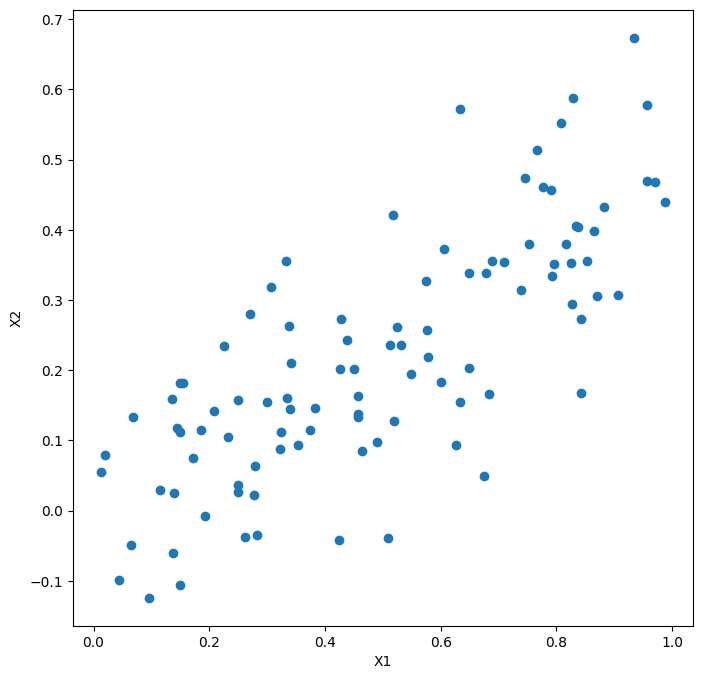

In [8]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x1, x2)
ax.set_xlabel('X1')
ax.set_ylabel('X2')

In [12]:
df = pd.DataFrame({'Y':y,
                   'X1':x1,
                   'X2':x2})
Corr_matrix = df.corr()
Corr_matrix

,Y,X1,X2
Y,1.000000,0.530531,0.471356
X1,0.530531,1.000000,0.772324
X2,0.471356,0.772324,1.000000


We plotted the relation between $X_{1}$ and $X_{2}$, and afterwards we show the correlation matrix between each of the variables. In particular we are interested in the correlation value between $X_{1}$ and $X_{2}$.

In [17]:
# Model Matrix
X = MS(['X1', 'X2']).fit_transform(df)
# Model
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,1.9579,0.190,10.319,0.000
X1,1.6154,0.527,3.065,0.003
X2,0.9428,0.831,1.134,0.259


The estimate coefficient $\hat{\beta_{1}}$ is a bit close to the actual value, and it's associated p-value is just below 0.05, which might allow us to reject the null hypothesis $H_{0}:\beta_{1}=0$. On the other hand, the estimated coefficient for $\hat{\beta_{2}}$ is far from the real value, and it's p-value is really high. Because it is far from 0, we could possibly reject the null hypothesis $H_{0}:\beta_{2}=0$, but it's value is still far from optimal.
Now lets see what happens if we fit a simple linear regression using only $X_1$.

In [19]:
# Model Matrix
X1 = MS(['X1']).fit_transform(df)
# Model
model1 = sm.OLS(y, X1)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,1.9371,0.189,10.242,0.0
X1,2.0771,0.335,6.196,0.0


C:\Users\vavic\AppData\Local\Temp\ipykernel_23792\2417405832.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results1.params[0], results1.params[1], 'r--', linewidth=3, label='Simple regression model 1')


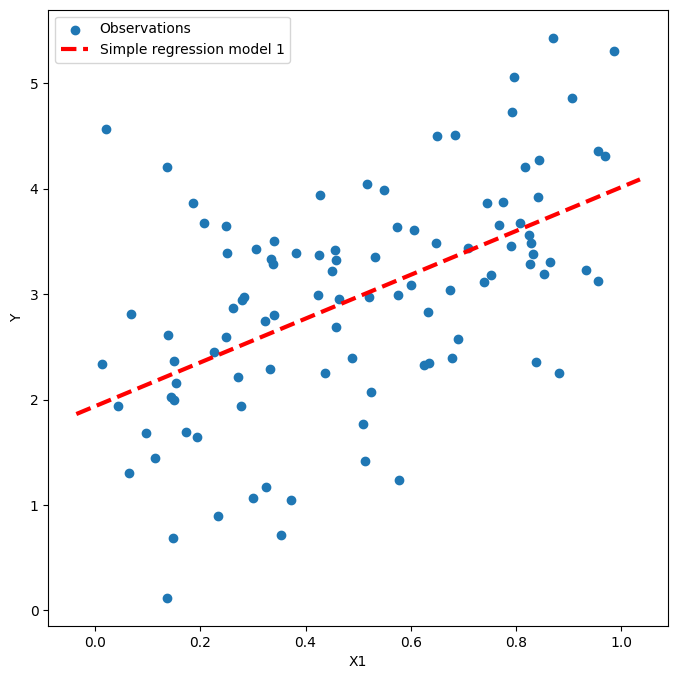

In [23]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x1, y, label='Observations')
abline(ax, results1.params[0], results1.params[1], 'r--', linewidth=3, label='Simple regression model 1')
ax.set_xlabel('X1')
ax.set_ylabel('Y')
ax.legend()

The practically zero p-value for $\hat{\beta_{1}}$ allows us to reject the null hypothesis $H_{0}:\beta_{1}=0$. 
Now we'll see what happens if we fit another simple linear regression model, but this time using only $X_{2}$.

In [21]:
# Model Matrix
X2 = MS(['X2']).fit_transform(df)
# Model
model2 = sm.OLS(y, X2)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,2.3239,0.154,15.124,0.0
X2,2.9103,0.550,5.291,0.0


C:\Users\vavic\AppData\Local\Temp\ipykernel_23792\3150771931.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results2.params[0], results2.params[1], 'r--', linewidth=3, label='Simple regression model 2')


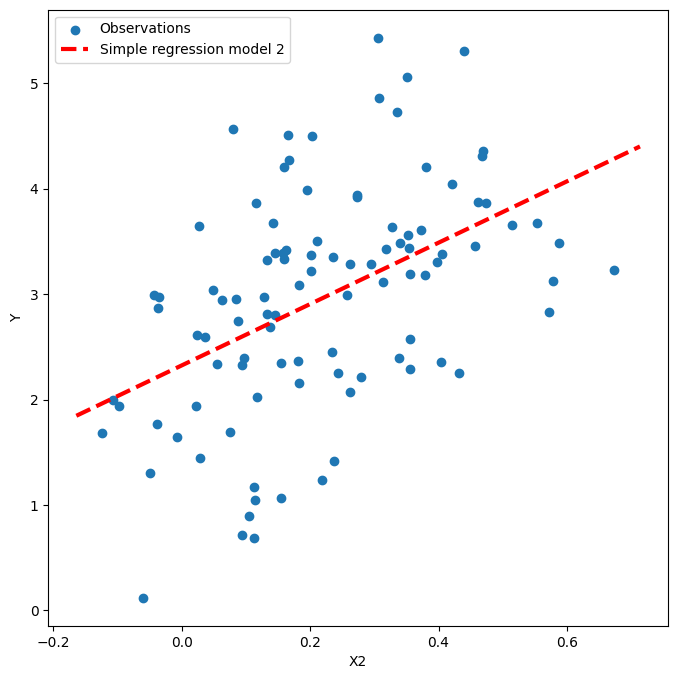

In [24]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x2, y, label='Observations')
abline(ax, results2.params[0], results2.params[1], 'r--', linewidth=3, label='Simple regression model 2')
ax.set_xlabel('X2')
ax.set_ylabel('Y')
ax.legend()

Even tough both models show p-values of almost 0 for all their coefficients, none of them seems to be a good fit for the actual data on their own. We might even be led to bealive that the results from the three different models contradict eachother, but this isn't necessarily the case. We actually know that the reason why the results are the way they are is due to the fact that $X_{2}$ was deffined as a linear function of $X_{1}$.

We'll now see what happens if we add another observation, using the np.concatenate() function:

In [25]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

We once again fit each of the three models

In [26]:
df = pd.DataFrame({'Y':y,
                   'X1':x1,
                   'X2':x2})

# Multiple linear regression model
# Model Matrix
X = MS(['X1', 'X2']).fit_transform(df)
# Model
model = sm.OLS(y, X)
results = model.fit()

# Simple regression using X1
# Model Matrix
X1 = MS(['X1']).fit_transform(df)
# Model
model1 = sm.OLS(y, X1)
results1 = model1.fit()

# Simple regression using X2
# Model Matrix
X2 = MS(['X2']).fit_transform(df)
# Model
model2 = sm.OLS(y, X2)
results2 = model2.fit()

In [27]:
summarize(results)

,coef,std err,t,P>|t|
intercept,2.0618,0.192,10.720,0.000
X1,0.8575,0.466,1.838,0.069
X2,2.2663,0.705,3.216,0.002


In [28]:
summarize(results1)

,coef,std err,t,P>|t|
intercept,2.0739,0.201,10.310,0.0
X1,1.8760,0.358,5.236,0.0


In [29]:
summarize(results2)

,coef,std err,t,P>|t|
intercept,2.2840,0.151,15.088,0.0
X2,3.1458,0.524,6.008,0.0


We see that, in all the models, the slope changed drastically, though the intercept remained almost unchanged. Is the new observation an outlier? A high-leverage point? Both? Maybe it's neither, and a poor fit of the model might be what's affecting so much the results.

## Excercise 15
Problem involving the **Boston** data set. We will try to predict per capita crime rate using all the other variables. The variables are labeled as follows:
* crim: per capita crime rate by town.
* zn: proportion of residential land zoned for lots over 25.000 sq.ft.
* indus: proportion of non-ratail business acres per town.
* chas: =1 if town bounds the Charles River, =0 otherwise.
* nox: nitrogen oxides concentration.
* rm: average number of rooms per dwelling.
* age: proportion of owner-occupied units build prior to 1940.
* dis: weighted mean of distances to five Boston employment centres.
* rad: index of accessibility to radial highways.
* tax: full-value property-tax rate per $10,000.
* ptratio: pupil-teacher ratio by town.
* lstat: lower status of the population (percent).
* medv: median value of owner-occupied homes in $1000s.

In [31]:
Boston = load_data('Boston')
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


First we'll fit a simple linear regression model using each of the variables: 

In [33]:
# Response Matrix
Y = Boston['crim']

C:\Users\vavic\AppData\Local\Temp\ipykernel_23792\2684824590.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3, label='OLS model')
C:\Users\vavic\AppData\Local\Temp\ipykernel_23792\2684824590.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3, label='OLS model')
C:\Users\vavic\AppData\Local\Temp\ipykernel_23792\2684824590.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consiste

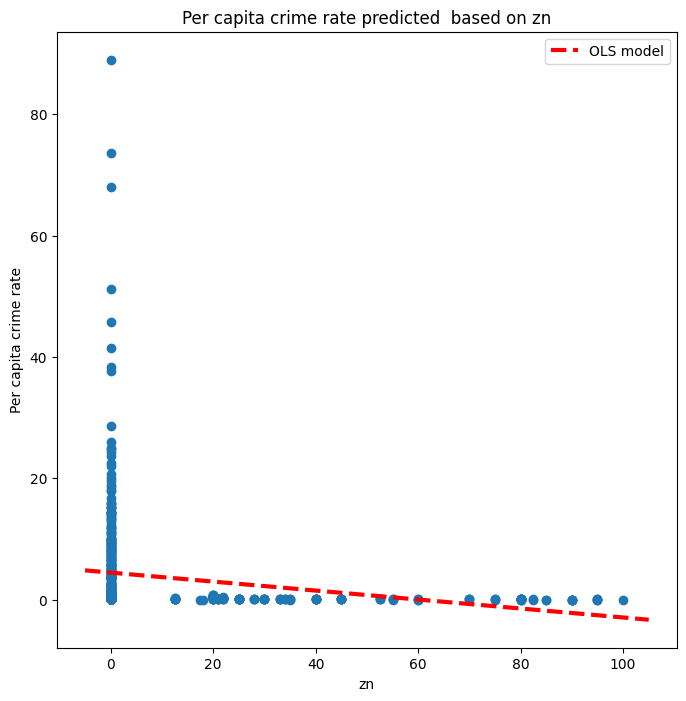

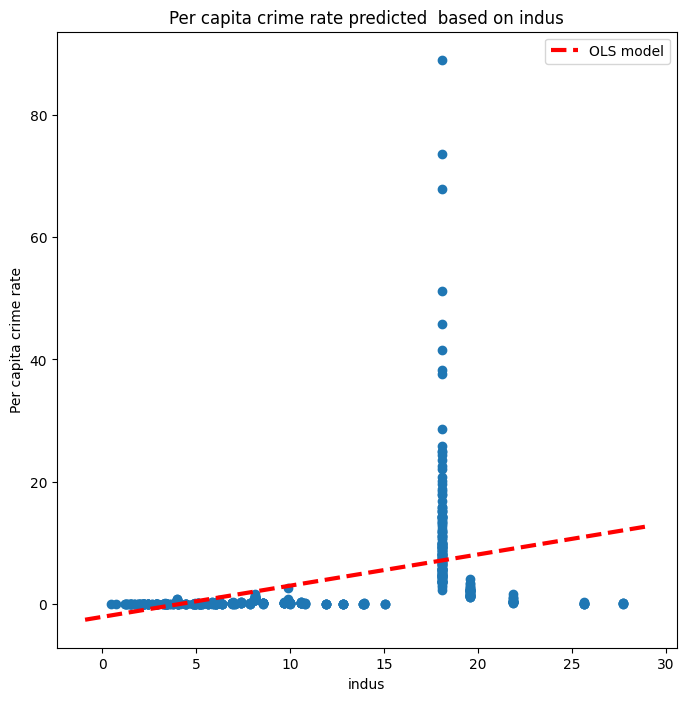

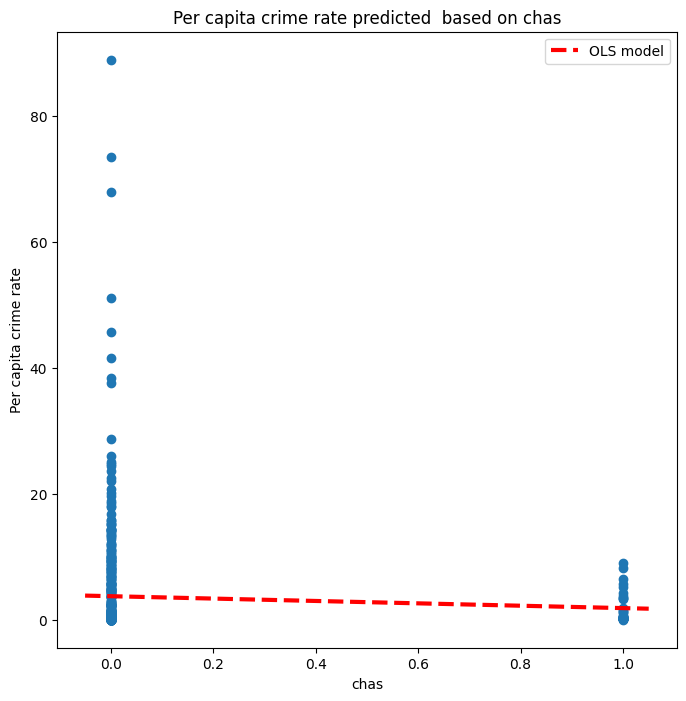

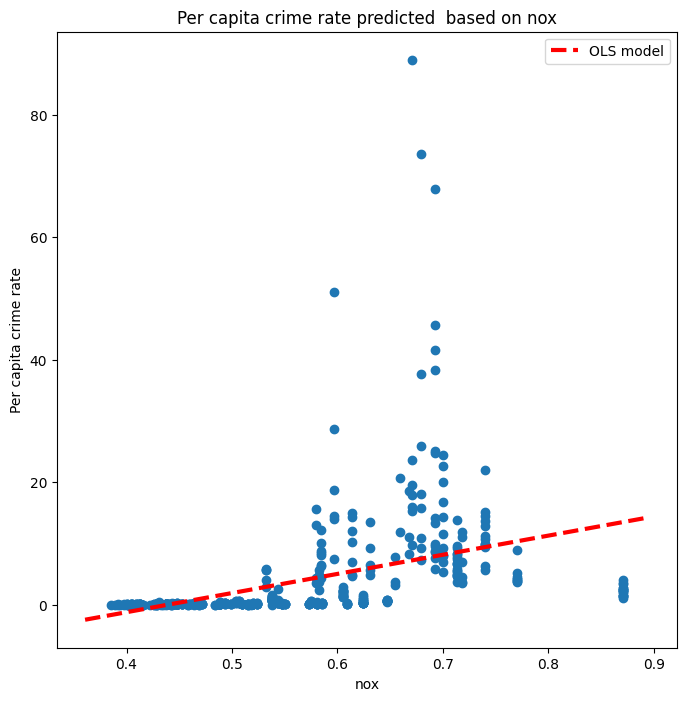

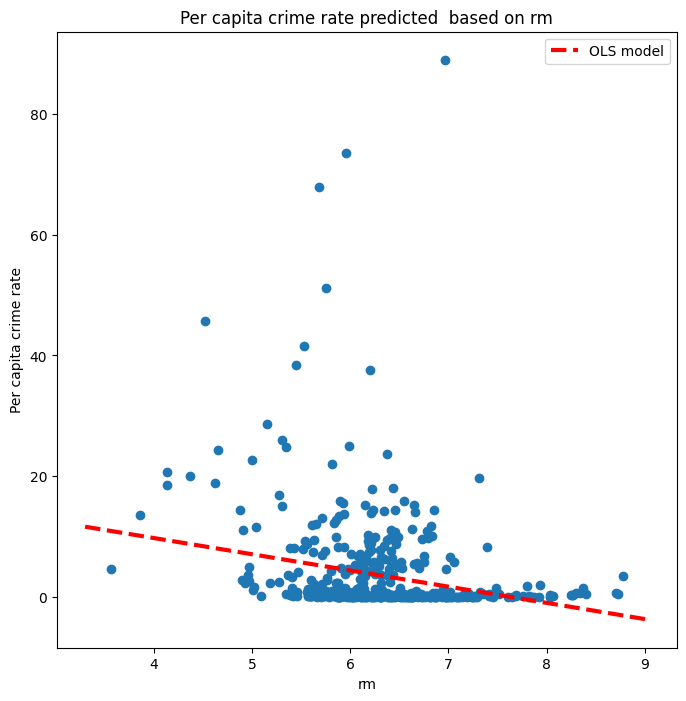

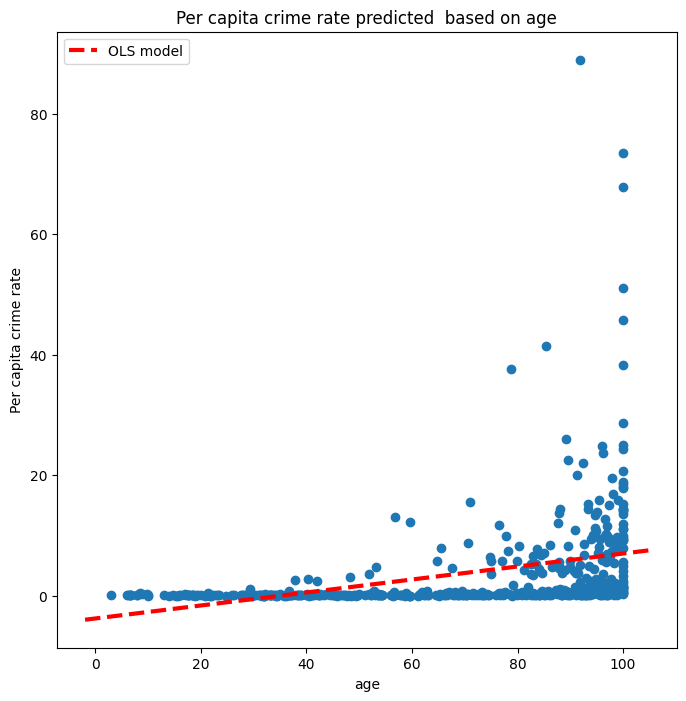

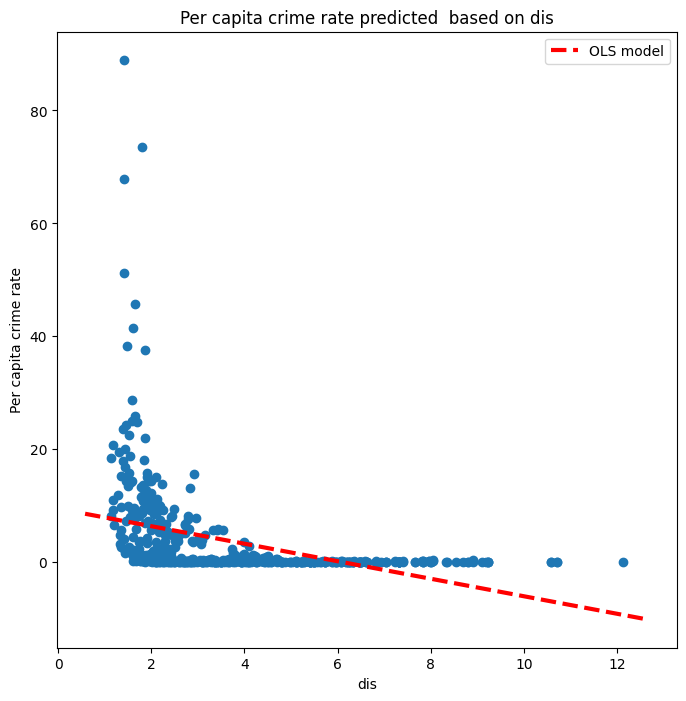

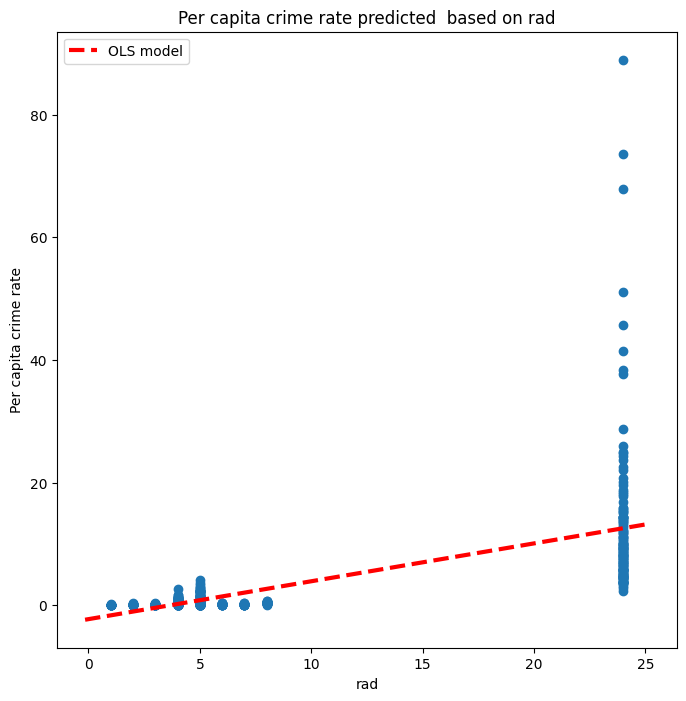

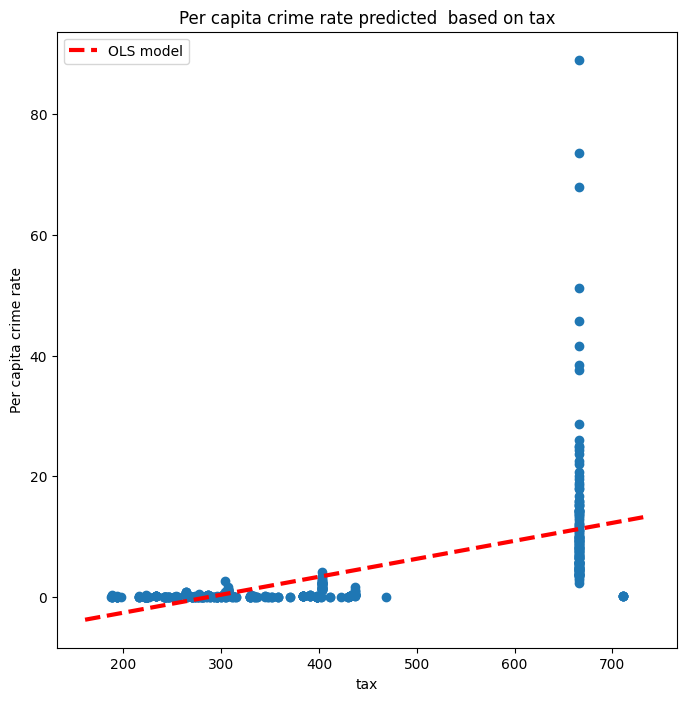

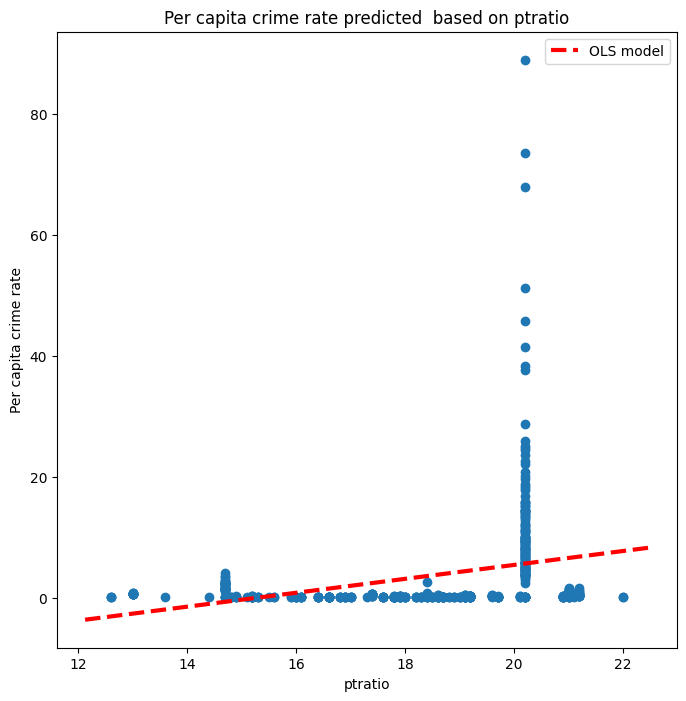

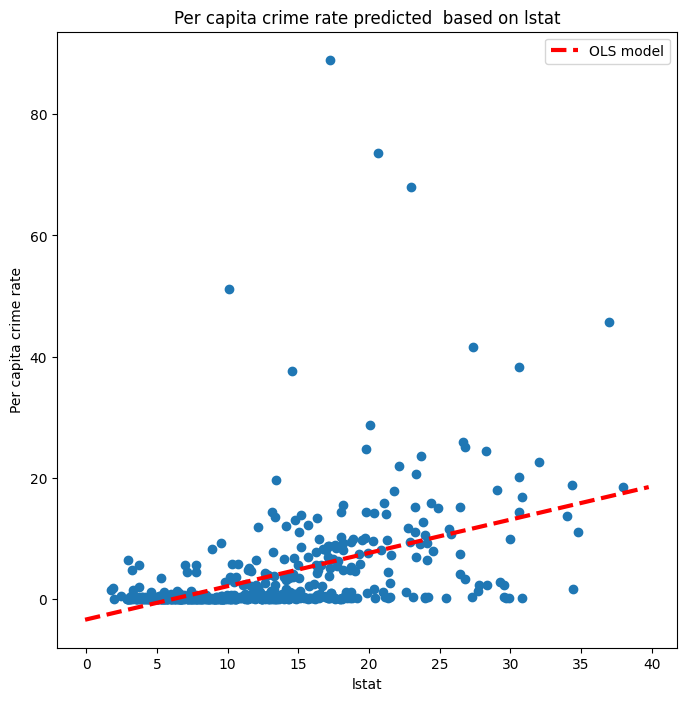

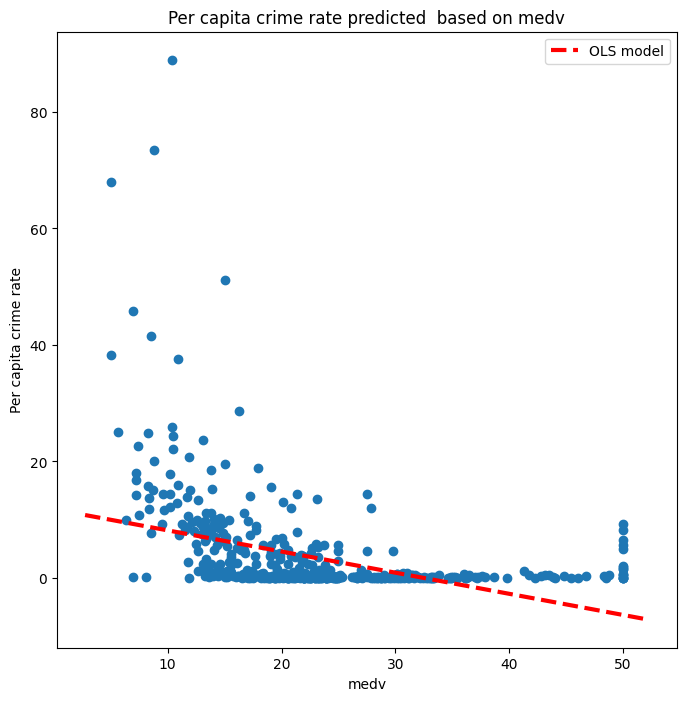

In [36]:
all_results = []
for column in Boston.columns.drop('crim'):
    X = MS([column]).fit_transform(Boston)          # Model Matrix
    model = sm.OLS(Y, X)                            # Ordinary least squares model
    results = model.fit()                           # Results

    # Save results
    all_results.append(results)

    # Plot
    ax = subplots(figsize=(8,8))[1]
    ax.scatter(Boston[column], Y)
    abline(ax, results.params[0], results.params[1], 'r--', linewidth=3, label='OLS model')
    ax.set_title(f'Per capita crime rate predicted  based on {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Per capita crime rate')
    ax.legend()

Without looking at the coefficients and p-values, it is clear that a linear model is not good enough for predicting per capita crime rate using each individual varaible. I would say that none of the models shows a statistically significant association between the predictor and the response.

In [38]:
for result in all_results:
    print(summarize(result))

             coef  std err       t  P>|t|
intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0
             coef  std err      t  P>|t|
intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000
             coef  std err      t  P>|t|
intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209
              coef  std err       t  P>|t|
intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0
              coef  std err      t  P>|t|
intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0
             coef  std err      t  P>|t|
intercept -3.7779    0.944 -4.002    0.0
age        0.1078    0.013  8.463    0.0
             coef  std err       t  P>|t|
intercept  9.4993    0.730  13.006    0.0
dis       -1.5509    0.168  -9.213    0.0
             coef  std err       t  P>|t|
intercept -2.2872    0.443  -5.157    0.0
rad        0.6179    0.034  17.998    0.

We can see that, for most of the predictors, the estimated coefficients show p-values of practically zero, even though, as seen in the different plots, none gives a good fit for the data.

Now, let's fit a multiple regression model using all predictors.

In [39]:
# List with the predictors
predictors = Boston.columns.drop('crim')
# Model matrix
X = MS(predictors).fit_transform(Boston)
# OLS model
model = sm.OLS(Y, X)
# Results
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


I would interpret that, the only coefficients that give statistically significant reasons to reject the null hypothesis $H_{0}:\beta_{j}=0$ are *dis*, *rad*, *medv* and maybe also *zn* and the intercept $\beta_{0}$.

In [50]:
src = []                                                # Single Regression Coefficients
for result in all_results:
    src.append(result.params[1])                    
mrc = []                                                # Multiple Regression Coefficients
for param in results.params:
    mrc.append(param)
mrc.pop(0)                                              # We remove the first coefficient (intercept)

C:\Users\vavic\AppData\Local\Temp\ipykernel_23792\2906861623.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  src.append(result.params[1])


13.778393786344067

Text(0, 0.5, 'Multivariate coefficients')

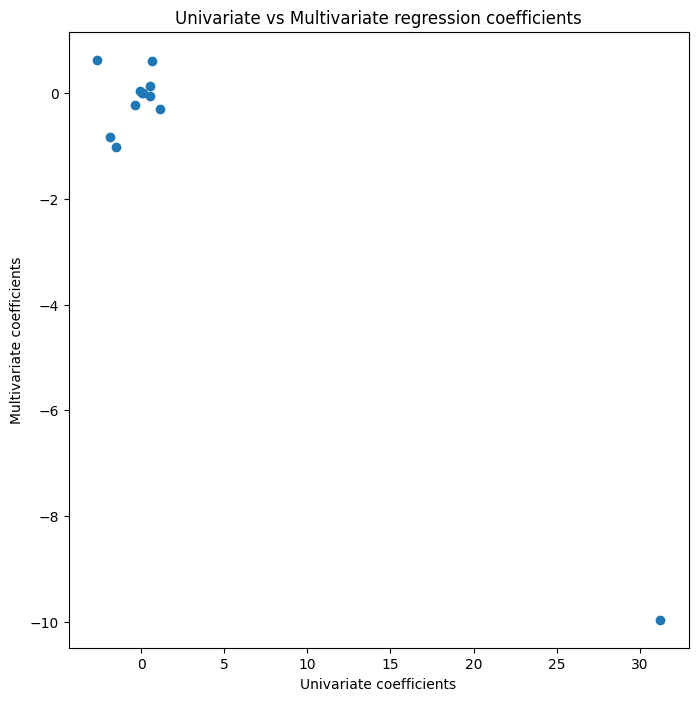

In [53]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(src,mrc)
ax.set_title('Univariate vs Multivariate regression coefficients')
ax.set_xlabel('Univariate coefficients')
ax.set_ylabel('Multivariate coefficients')

For most parameters (except *nox*) the multivariate coefficient lies near zero, and the univariate coefficient isn't to far. The *nox* parameter, on the other hand, shows a very different value for it's coefficient in the simple linear regression compared to the multiple linear regression.